# Price Prediction — Prague Airbnb

**Focus Area 1: Price Prediction** (Group 13 — Prague)

This notebook implements:
1. scikit-learn `Pipeline` (imputer + scaler + model)
2. Train/test split comparison (random / neighbourhood / host)
3. Model comparison (Ridge, Random Forest, Gradient Boosting, KNN)
4. Hyperparameter tuning (`GridSearchCV` vs `RandomizedSearchCV`)

**Target:** `price_log = log1p(price)` in Czech Koruna (CZK)

**Features:** 10 variables for **primary results** (`DEFAULT_FEATURES`), derived from teammate RF feature selection (95% cumulative importance). We exclude `estimated_revenue_l365d_log` from main reporting because it is derived from price (target leakage). The full 11-feature set is kept only for a sensitivity check.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from price_modeling import (
    DEFAULT_FEATURES,
    SELECTED_FEATURES,
    SELECTED_FEATURES_NO_LEAK,
    build_pipeline,
    compare_models,
    cross_validate_model,
    evaluate_predictions,
    get_xy,
    hyperparameter_search,
    load_or_build_dataset,
    make_split,
    outputs_dir,
)

sns.set_theme(style="whitegrid")
print("Project root:", ROOT)

Project root: D:\UsersData\Desktop\Data Science for Biz


## 1. Load data

Uses teammate module `data_prepro_func.get_release_df()`.

Priority:
1. `data/airbnb_listings_features.csv.gz` (local)
2. GitHub Release tag `data` via `get_release_df("airbnb_listings_features.csv.gz")`
3. Fallback: `listings.csv.gz` (local or Release) and rebuild features

In [2]:
dataset = load_or_build_dataset()
print("Rows:", len(dataset))
print("Columns:", list(dataset.columns))
dataset.head()

Loaded local file: D:\UsersData\Desktop\Data Science for Biz\data\airbnb_listings_features.csv.gz
Loaded local file: D:\UsersData\Desktop\Data Science for Biz\data\listings.csv.gz


Rows: 9498
Columns: ['Unnamed: 0', 'id', 'name', 'bedrooms_log', 'estimated_revenue_l365d_log', 'property_type_clean_Private room in rental unit', 'bathrooms_log', 'room_type_Shared room', 'host_response_rate', 'availability_365', 'estimated_occupancy_l365d', 'reviews_per_month_log', 'calculated_host_listings_count_entire_homes_log', 'availability_60', 'price_log', 'neighbourhood_cleansed', 'host_id']


,Unnamed: 0,id,name,bedrooms_log,estimated_revenue_l365d_log,property_type_clean_Private room in rental unit,bathrooms_log,room_type_Shared room,host_response_rate,availability_365,estimated_occupancy_l365d,reviews_per_month_log,calculated_host_listings_count_entire_homes_log,availability_60,price_log,neighbourhood_cleansed,host_id
0,2,26755,Central Prague Old Town Top Floor,0.693147,13.269681,0,0.916291,0,1.00,142,255,1.501853,1.386294,11,7.728856,Praha 1,113902
1,4,42514,"""NEWLY FURNISHED"" 1BR near Pachtuv Palace,Old ...",0.693147,0.000000,0,0.693147,0,0.33,362,0,1.033184,0.693147,57,7.967627,Praha 1,185641
2,5,52148,Colorful 2BDR Family Apartment,0.693147,13.111114,0,0.693147,0,1.00,121,198,0.959350,4.564348,27,7.823246,Praha 2,227945
3,6,55856,Renovated Apartment behind National Museum,0.693147,13.169297,0,0.693147,0,1.00,125,255,1.214913,4.564348,33,7.628518,Praha 2,227945
4,7,75298,Prague Studio Old Town,0.693147,9.151333,0,0.693147,0,1.00,320,6,0.285179,1.098612,35,7.360104,Praha 1,398991


## 2. Pipeline design

Each model uses the same preprocessing inside a sklearn `Pipeline`:

```
SimpleImputer(median) -> StandardScaler -> Model
```

**Why Pipeline?** Course requirement + prevents data leakage from fitting imputer/scaler on test data.

In [3]:
example_pipe = build_pipeline("random_forest")
example_pipe

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

## 3. Split strategy comparison

Case study asks whether some clusters should stay only in train or test.

We compare:
- **random**: standard 80/20 split
- **neighbourhood**: `GroupShuffleSplit` by Prague district
- **host**: `GroupShuffleSplit` by `host_id` (prevents same host in both sets)

**Reasoning:** Random split is optimistic when similar hosts or districts appear in both sets. Group splits simulate deploying the model to unseen hosts or neighbourhoods. We report **RMSE/MAE/R² on log-price** as the primary metric because the target is log-transformed; CZK-scale metrics are shown for business interpretation.

In [4]:
split_frames = []
split_predictions = {}

for strategy, groups_col in [
    ("random", None),
    ("neighbourhood", "neighbourhood_cleansed"),
    ("host", "host_id"),
]:
    X, y, groups_neighbourhood, groups_host = get_xy(dataset, DEFAULT_FEATURES)
    groups = groups_neighbourhood if groups_col == "neighbourhood_cleansed" else (
        groups_host if groups_col == "host_id" else None
    )

    if strategy != "random" and groups is None:
        print(f"Skipping split '{strategy}' because group column is unavailable.")
        continue

    X_train, X_test, y_train, y_test = make_split(X, y, strategy=strategy, groups=groups)
    comparison = compare_models(X_train, X_test, y_train, y_test)
    comparison.insert(0, "split", strategy)
    split_frames.append(comparison)

    best_name = comparison.iloc[0]["model"]
    best_pipe = build_pipeline(best_name)
    best_pipe.fit(X_train, y_train)
    split_predictions[strategy] = pd.DataFrame({
        "y_true_log": y_test,
        "y_pred_log": best_pipe.predict(X_test),
    })

split_comparison = pd.concat(split_frames, ignore_index=True)
split_comparison

,split,model,rmse_log,mae_log,r2_log,rmse_czk,mae_czk,r2_czk
0,random,random_forest,0.412617,0.282029,0.600393,7512.585033,1211.598778,0.695705
1,random,gradient_boosting,0.423752,0.304617,0.578536,9358.091759,1452.976027,0.527838
2,random,knn,0.449746,0.313012,0.525242,8549.736458,1351.246872,0.605886
3,random,ridge,0.498494,0.345129,0.416745,13471.762222,1766.200442,0.021490
4,neighbourhood,random_forest,0.504539,0.372352,0.186400,9823.528884,1374.993673,-15.792489
5,neighbourhood,gradient_boosting,0.510085,0.378044,0.168413,8839.861615,1271.982986,-12.597872
6,neighbourhood,ridge,0.522263,0.403752,0.128233,2390.490800,1020.465664,0.005616
7,neighbourhood,knn,0.545040,0.402754,0.050537,8840.860057,1338.552906,-12.600944
8,host,random_forest,0.493148,0.349778,0.333412,7837.229928,1285.301068,0.019858
9,host,knn,0.503307,0.366409,0.305667,7819.618207,1317.541204,0.024259


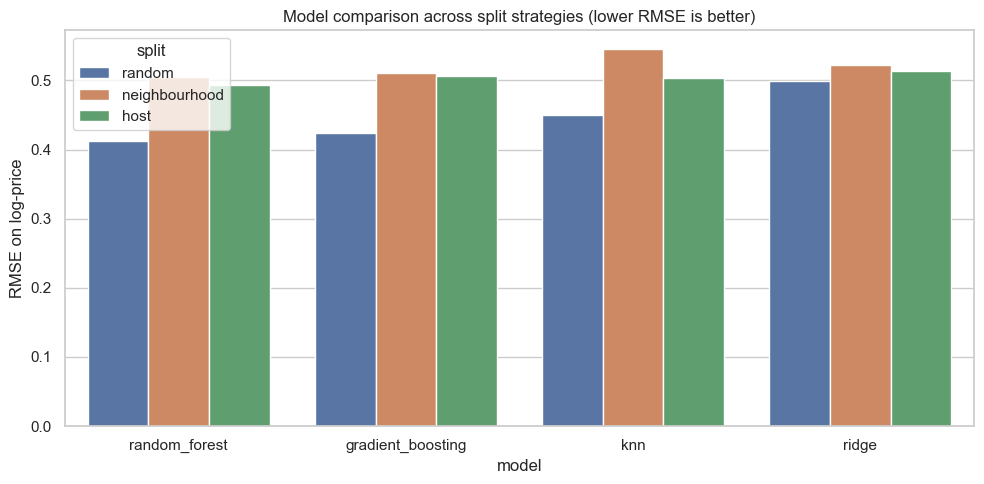

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=split_comparison, x="model", y="rmse_log", hue="split", ax=ax)
ax.set_title("Model comparison across split strategies (lower RMSE is better)")
ax.set_ylabel("RMSE on log-price")
plt.tight_layout()
plt.savefig(outputs_dir() / "split_model_comparison.png", dpi=150)
plt.show()

split_comparison.to_csv(outputs_dir() / "model_comparison_by_split.csv", index=False)

### Leakage check: `estimated_revenue_l365d_log`

Estimated annual revenue is derived from price, so it can inflate test performance. We compare models with and without this feature.

In [6]:
leakage_frames = []
for features, label in [
    (SELECTED_FEATURES, "with_revenue_feature"),
    (SELECTED_FEATURES_NO_LEAK, "without_revenue_feature"),
]:
    X, y, _, _ = get_xy(dataset, features)
    X_train, X_test, y_train, y_test = make_split(X, y, strategy="random")
    comparison = compare_models(X_train, X_test, y_train, y_test)
    comparison.insert(0, "feature_set", label)
    leakage_frames.append(comparison)

leakage_df = pd.concat(leakage_frames, ignore_index=True)
leakage_df

,feature_set,model,rmse_log,mae_log,r2_log,rmse_czk,mae_czk,r2_czk
0,with_revenue_feature,random_forest,0.247853,0.094648,0.855813,5402.044168,667.334042,0.842662
1,with_revenue_feature,gradient_boosting,0.281784,0.162373,0.813632,10414.617175,1130.222281,0.415206
2,with_revenue_feature,knn,0.433157,0.299881,0.559619,8706.957042,1336.650890,0.591258
3,with_revenue_feature,ridge,0.498491,0.345214,0.416752,13470.780119,1766.475506,0.021633
4,without_revenue_feature,random_forest,0.412617,0.282029,0.600393,7512.585033,1211.598778,0.695705
5,without_revenue_feature,gradient_boosting,0.423752,0.304617,0.578536,9358.091759,1452.976027,0.527838
6,without_revenue_feature,knn,0.449746,0.313012,0.525242,8549.736458,1351.246872,0.605886
7,without_revenue_feature,ridge,0.498494,0.345129,0.416745,13471.762222,1766.200442,0.021490


## 4. Cross-validation on training set

5-fold CV on the best baseline model from the **no-leak** feature set, using random-split training data.

**Reasoning:** CV estimates stability before hyperparameter tuning. We keep tuning on the same training fold to avoid peeking at the test set.

In [7]:
X, y, _, _ = get_xy(dataset, DEFAULT_FEATURES)
X_train, X_test, y_train, y_test = make_split(X, y, strategy="random")

baseline = compare_models(X_train, X_test, y_train, y_test)
best_model_name = baseline.iloc[0]["model"]
print("Best baseline model:", best_model_name)
display(baseline)

cv_results = cross_validate_model(X_train, y_train, model_name=best_model_name, cv=5)
cv_results.to_csv(outputs_dir() / f"cv_{best_model_name}.csv", index=False)
cv_results

Best baseline model: random_forest


,model,rmse_log,mae_log,r2_log,rmse_czk,mae_czk,r2_czk
1,random_forest,0.412617,0.282029,0.600393,7512.585033,1211.598778,0.695705
2,gradient_boosting,0.423752,0.304617,0.578536,9358.091759,1452.976027,0.527838
3,knn,0.449746,0.313012,0.525242,8549.736458,1351.246872,0.605886
0,ridge,0.498494,0.345129,0.416745,13471.762222,1766.200442,0.021490


,metric,mean,std
0,rmse_log,0.446687,0.018394
1,mae_log,0.289683,0.003297
2,r2_log,0.590443,0.029153


## 5. Hyperparameter tuning

We tune the best model with two methods required by the case study:
- `GridSearchCV` (exhaustive small grid)
- `RandomizedSearchCV` (random search over same space)

**Reasoning:** GridSearch is reproducible and fine for a small parameter space. RandomizedSearch scales better when the grid grows; we use both to compare search strategies as required by the case study.

In [8]:
tuned_grid, grid_results = hyperparameter_search(
    X_train, y_train, model_name=best_model_name, method="grid", cv=3
)
tuned_random, random_results = hyperparameter_search(
    X_train, y_train, model_name=best_model_name, method="random", cv=3
)

grid_results.head(10).to_csv(outputs_dir() / "grid_search_top10.csv", index=False)
random_results.head(10).to_csv(outputs_dir() / "random_search_top10.csv", index=False)

print("GridSearch best params:")
print(tuned_grid.named_steps["model"].get_params())

grid_test = evaluate_predictions(y_test, tuned_grid.predict(X_test))
random_test = evaluate_predictions(y_test, tuned_random.predict(X_test))

tuning_comparison = pd.DataFrame([
    {"method": "grid_search", **grid_test},
    {"method": "random_search", **random_test},
])
tuning_comparison.to_csv(outputs_dir() / "tuning_comparison.csv", index=False)
tuning_comparison

GridSearch best params:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


,method,rmse_log,mae_log,r2_log,rmse_czk,mae_czk,r2_czk
0,grid_search,0.411192,0.281927,0.603149,7788.760559,1260.859304,0.672921
1,random_search,0.411192,0.281927,0.603149,7788.760559,1260.859304,0.672921


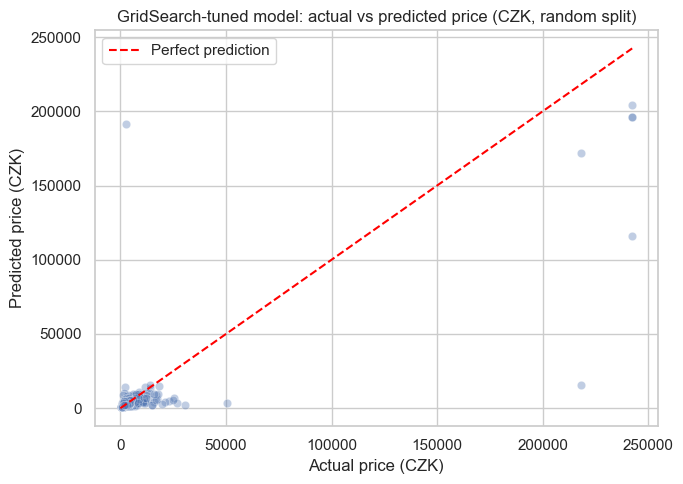

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = pd.DataFrame({
    "y_true_log": y_test,
    "y_pred_log": tuned_grid.predict(X_test),
})
plot_df["price_true"] = np.expm1(plot_df["y_true_log"])
plot_df["price_pred"] = np.expm1(plot_df["y_pred_log"])

sns.scatterplot(data=plot_df, x="price_true", y="price_pred", alpha=0.35, ax=ax)
max_price = plot_df[["price_true", "price_pred"]].max().max()
ax.plot([0, max_price], [0, max_price], linestyle="--", color="red", label="Perfect prediction")
ax.set_title("GridSearch-tuned model: actual vs predicted price (CZK, random split)")
ax.set_xlabel("Actual price (CZK)")
ax.set_ylabel("Predicted price (CZK)")
ax.legend()
plt.tight_layout()
plt.savefig(outputs_dir() / "actual_vs_predicted.png", dpi=150)
plt.show()

## 6. Key takeaways for presentation

1. **Primary results use 10 no-leak features**; `estimated_revenue_l365d_log` is shown only as a sensitivity check.
2. **Random Forest + Pipeline** works best among tested models on log-price.
3. **Group splits are harder than random split** — performance drops when neighbourhoods or hosts do not overlap between train and test. Compare splits using **log-price metrics**; CZK-scale R² can look unstable after `expm1`.
4. **GridSearch and RandomSearch** reach similar test performance; GridSearch is more reproducible on our small grid.
5. **Business angle:** bedrooms, bathrooms, availability, and host activity drive Prague listing prices; the model supports hosts benchmarking against similar properties.